In [1]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install lime

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [273]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Stacking
from sklearn.ensemble import StackingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Imbalanced learning
from imblearn.over_sampling import SMOTE


In [369]:
# Load dataset
ch = pd.read_csv(r"C:\Users\Latitude\Downloads\Churn_Modelling.csv")
ch

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# data analysis

In [370]:
ch.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [371]:
ch.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [372]:
ch.shape

(10000, 14)

In [373]:
ch.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [374]:
ch.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [375]:
ch.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [376]:
ch.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [377]:
ch.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [378]:
ch.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [ ]:
# Convert Date column
ch['EstimatedSalary'] = pd.to_datetime(ch['EstimatedSalary'])

# Sales over time
plt.figure()
ch.groupby('EstimatedSalary')['Age'].mean().plot()
plt.title("Income_Age")
plt.show()

KeyError: 'Annual_Income'

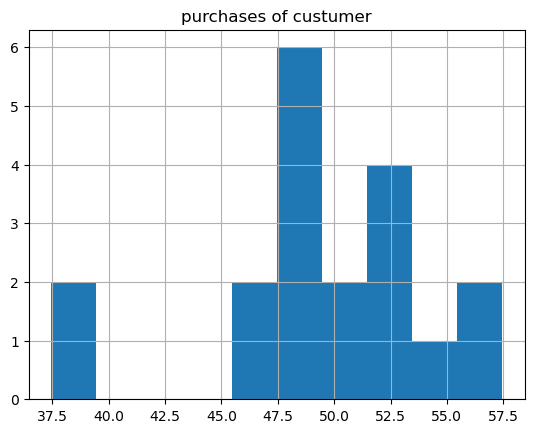

In [285]:
# Sales over time
plt.figure()
ch.groupby('Years_as_Customer')['Num_of_Purchases'].mean().hist()
plt.title("purchases of custumer")
plt.show()

In [286]:
ch.groupby("Age")["Total_Spend"].sum().sort_values()

Age
29     50325.62
20     54542.14
49     56467.65
32     64944.86
46     66030.17
62     71113.28
60     71891.10
40     73058.48
33     74062.05
39     77881.44
35     80856.49
43     81005.02
57     81279.67
58     82321.32
55     82570.87
47     82655.98
65     84577.62
67     85131.40
59     85625.69
66     87631.75
22     89451.51
31     90060.44
19     91117.15
24     91197.96
51     96523.46
28     98963.79
38     99012.92
52    101371.98
26    101925.76
44    102028.52
50    102700.11
61    103137.25
56    104244.82
64    105108.55
42    105274.34
36    107632.05
48    107873.83
69    110948.92
34    113275.02
63    114466.62
41    115032.82
30    115854.91
25    116939.10
27    119654.82
68    120060.74
53    121689.61
54    123534.29
23    124861.82
45    130216.16
18    132190.34
37    139086.46
21    191383.98
Name: Total_Spend, dtype: float64

In [287]:
ch.groupby("Annual_Income")["Years_as_Customer"].sum().sort_values()

Annual_Income
1970-01-01 00:00:00.000000104      6
1970-01-01 00:00:00.000000166      6
1970-01-01 00:00:00.000000023      7
1970-01-01 00:00:00.000000063      7
1970-01-01 00:00:00.000000109      9
                                ... 
1970-01-01 00:00:00.000000040    114
1970-01-01 00:00:00.000000167    115
1970-01-01 00:00:00.000000077    141
1970-01-01 00:00:00.000000115    142
1970-01-01 00:00:00.000000158    152
Name: Years_as_Customer, Length: 180, dtype: int64

In [288]:
ch.pivot_table(index="Num_of_Purchases", values="Promotion_Response", aggfunc="sum")\
  .sort_values(by="Promotion_Response", ascending=True)

,Promotion_Response
Num_of_Purchases,
28,IgnoredIgnoredIgnoredUnsubscribedUnsubscribedU...
48,IgnoredIgnoredRespondedUnsubscribedIgnoredResp...
23,IgnoredIgnoredRespondedUnsubscribedRespondedRe...
98,IgnoredIgnoredUnsubscribedUnsubscribedResponde...
84,IgnoredIgnoredUnsubscribedUnsubscribedUnsubscr...
...,...
54,UnsubscribedUnsubscribedRespondedIgnoredIgnore...
70,UnsubscribedUnsubscribedRespondedRespondedUnsu...
47,UnsubscribedUnsubscribedRespondedUnsubscribed


In [289]:
ch.pivot_table(index="Promotion_Response", values="Average_Transaction_Amount", aggfunc="mean")\
  .sort_values(by="Promotion_Response", ascending=False)

,Average_Transaction_Amount
Promotion_Response,
Unsubscribed,273.436177
Responded,255.007249
Ignored,272.337608


In [290]:
ch.pivot_table(index="Last_Purchase_Days_Ago", values="Num_of_Purchases", aggfunc="count")\
  .sort_values(by="Last_Purchase_Days_Ago")

,Num_of_Purchases
Last_Purchase_Days_Ago,
1,2
2,1
3,1
4,6
5,3
...,...
360,6
361,3
362,1


<Axes: ylabel='count'>

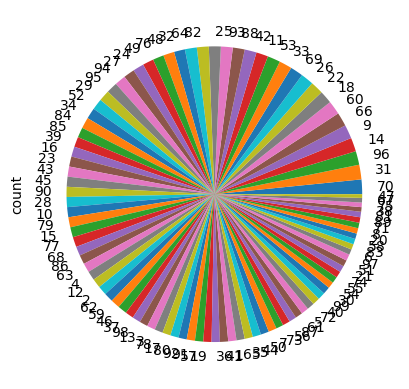

In [291]:
ch['Num_of_Purchases'].value_counts().plot(kind="pie")

<Axes: xlabel='Average_Transaction_Amount'>

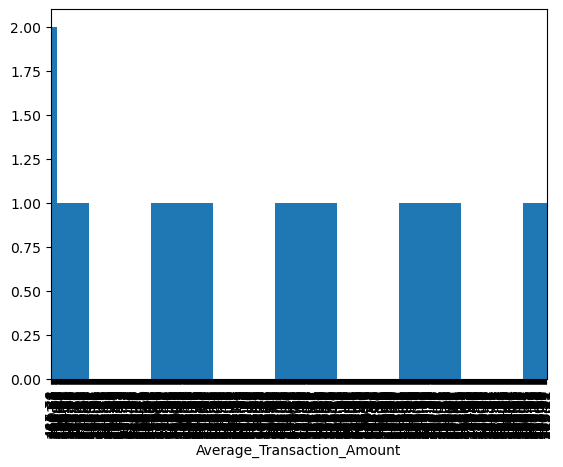

In [292]:
ch['Average_Transaction_Amount'].value_counts().plot(kind="bar")

<Axes: ylabel='Frequency'>

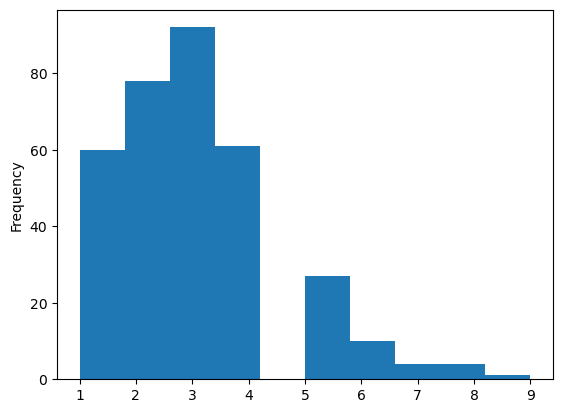

In [293]:
ch['Last_Purchase_Days_Ago'].value_counts().plot(kind="hist") 

<Axes: xlabel='Years_as_Customer'>

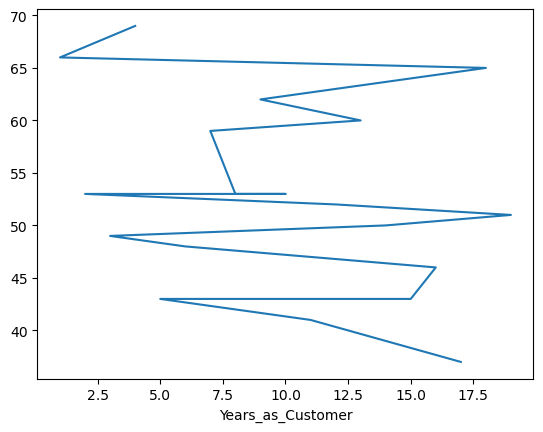

In [294]:
ch['Years_as_Customer'].value_counts().plot(kind="line")

<Axes: xlabel='Years_as_Customer', ylabel='Num_of_Purchases'>

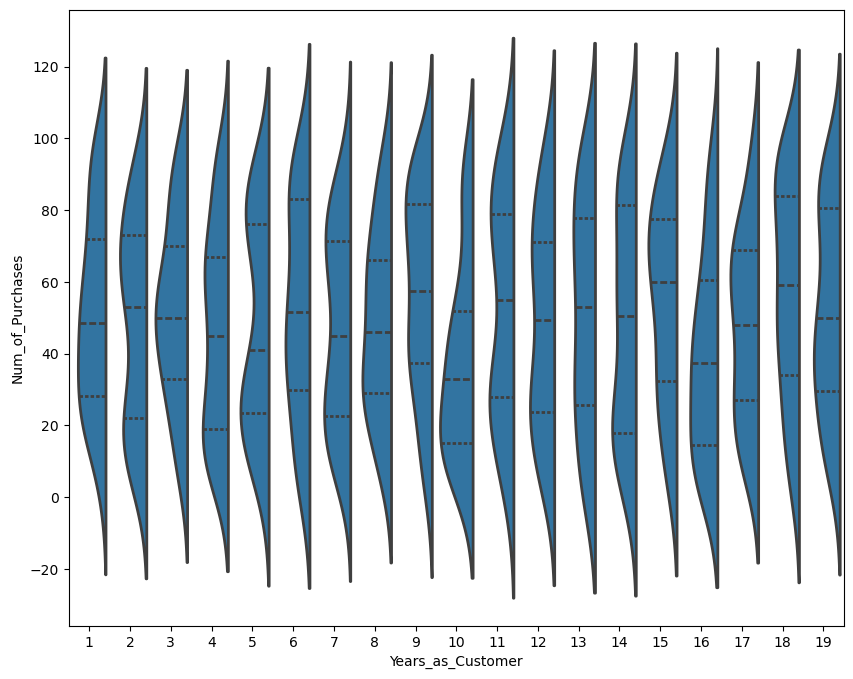

In [295]:
plt.figure(figsize =(10,8))
sns.violinplot(data=ch,x="Years_as_Customer", y="Num_of_Purchases", split= True, linewidth=2, inner ="quart")

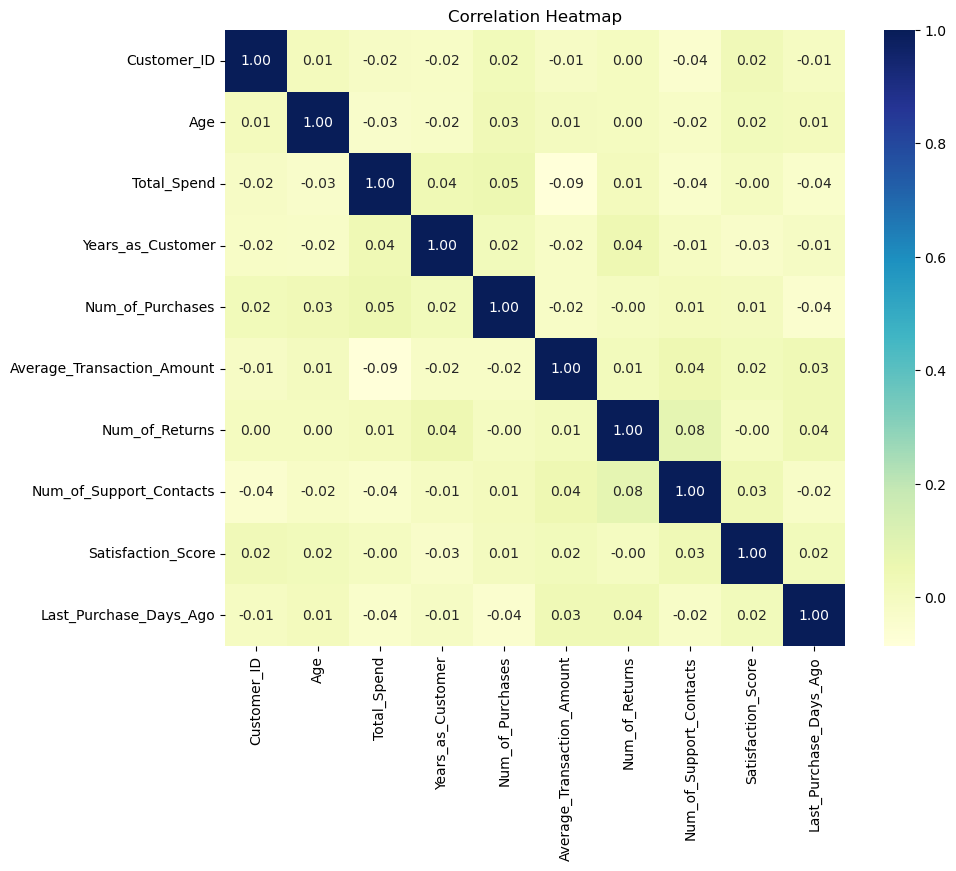

In [296]:
# Correlation plot of numerical independent variables

plt.figure(figsize=(10, 8))

# Select only numerical columns
numeric_data = ch.select_dtypes(include="number")

# Create correlation heatmap
sns.heatmap(
    numeric_data.corr(), annot=True, fmt=".2f", cmap="YlGnBu")

plt.title("Correlation Heatmap")
plt.show()

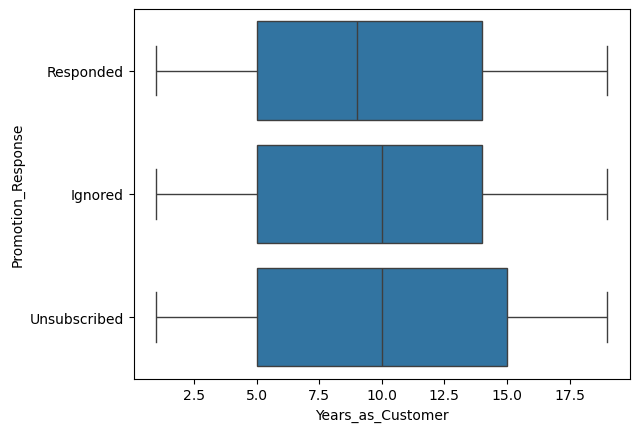

In [297]:
# Box plot
sns.boxplot(data=ch, x="Years_as_Customer", y="Promotion_Response")
plt.show()

In [396]:
# Remove extra spaces from column names
ch.columns = ch.columns.str.strip()

# Check column names again
print(ch.columns.tolist())

['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [395]:
# Check missing values
print(ch.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [397]:
numeric_cols = ch.select_dtypes(include=np.number).columns

ch[numeric_cols] = ch[numeric_cols].fillna(
    ch[numeric_cols].median()
)

In [398]:
categorical_cols = ch.select_dtypes(include="object").columns

for col in categorical_cols:
    ch[col] = ch[col].fillna(ch[col].mode()[0])


# Feature Engineering

In [399]:
ch["Average_Spend_Per_Purchase"] = (
    ch["CreditScore"] /
    ch["NumOfProducts"].replace(0, 1)
)

In [400]:
ch["Return_Rate"] = (
    ch["EstimatedSalary"] /
    ch["NumOfProducts"].replace(0, 1)
)

In [403]:
ch["Purchase_Frequency"] = (
    ch["NumOfProducts"] /
    ch["IsActiveMember"].replace(0, 1)
)

# Handle date columns

In [404]:
ch["IsActiveMember"] = pd.to_datetime(
    ch["IsActiveMember"],
    errors="coerce"
)

In [405]:
ch["IsActiveMember"] = (
    pd.Timestamp.today() -
    ch["IsActiveMember"]
).dt.days

In [406]:
ch.drop("IsActiveMember", axis=1, inplace=True)

# Separate X and y

In [407]:
X = ch.iloc[:, :-1]
y = ch.iloc[:, -1]

In [408]:
target = "Exited"

X = ch.drop(target, axis=1)
y = ch[target].astype(int)

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

In [409]:
X = ch.drop(columns=["Exited", "CustomerId"])
y = ch["Exited"].astype(int)

In [410]:
print(X.dtypes)

RowNumber                       int64
Surname                        object
CreditScore                     int64
Geography                      object
Gender                         object
Age                             int64
Tenure                          int64
Balance                       float64
NumOfProducts                   int64
HasCrCard                       int64
EstimatedSalary               float64
Average_Spend_Per_Purchase    float64
Return_Rate                   float64
Purchase_Frequency            float64
dtype: object


In [415]:
# Feature Engineering

X["Average_Spend_Per_Purchase"] = (
    X["Average_Spend_Per_Purchase"] /
    X["NumOfProducts"].replace(0, 1)
)

X["Return_Rate"] = (
    X["Return_Rate"] /
    X["NumOfProducts"].replace(0, 1)
)

X["Purchase_Frequency"] = (
    X["NumOfProducts"] /
    X["Purchase_Frequency"].replace(0, 1)
)

X["Support_Per_Purchase"] = (
    X["Balance"] /
    X["NumOfProducts"].replace(0, 1)
)

X["Spend_Per_Year"] = (
    X["Average_Spend_Per_Purchase"] /
    X["Purchase_Frequency"].replace(0, 1)
)

# Encode target

In [416]:
le = LabelEncoder()

y = le.fit_transform(y)

print(np.unique(y)) 
#0 = No Churn
#1 = Churn


[0 1]


# Identify categorical columns

In [417]:
categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['Surname', 'Geography', 'Gender']


In [418]:
for col in categorical_columns:
    X[col] = X[col].astype("category").cat.codes

# Train , Test and Split

In [419]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [423]:
print("X_train_scaled:", X_train_scaled.shape)
print("y_train:", y_train.shape)

X_train_scaled: (800, 18)
y_train: (8000,)


In [426]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# --------------------------------------------------
# 1. Separate features and target
# --------------------------------------------------

# CHANGE "Target_Churn" to the actual target column
X = ch.drop("Exited", axis=1)
y = ch["Exited"]

print("X shape:", X.shape)
print("y shape:", y.shape)


# --------------------------------------------------
# 2. Convert categorical columns to numbers
# --------------------------------------------------

X = pd.get_dummies(X, drop_first=True)

# Convert True/False to 0/1
X = X.astype(float)

print("Encoded X shape:", X.shape)


# --------------------------------------------------
# 3. Split X and y TOGETHER
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


# --------------------------------------------------
# 4. Scale the data
# --------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled X_train:", X_train_scaled.shape)
print("Scaled X_test:", X_test_scaled.shape)


# --------------------------------------------------
# 5. Apply SMOTE ONLY to training data
# --------------------------------------------------

smote = SMOTE(random_state=42)

X_train_balanced_Scaled, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)


# --------------------------------------------------
# 6. Check before and after balancing
# --------------------------------------------------

print("\nBefore balancing:")
print(pd.Series(y_train).value_counts())

print("\nAfter balancing:")
print(pd.Series(y_train_balanced).value_counts())

print("\nFinal shapes:")
print("X_train_balanced_Scaled:", X_train_balanced_Scaled.shape)
print("y_train_balanced:", y_train_balanced.shape)

X shape: (10000, 15)
y shape: (10000,)
Encoded X shape: (10000, 2946)
X_train: (8000, 2946)
y_train: (8000,)
X_test: (2000, 2946)
y_test: (2000,)
Scaled X_train: (8000, 2946)
Scaled X_test: (2000, 2946)

Before balancing:
Exited
0    6370
1    1630
Name: count, dtype: int64

After balancing:
Exited
1    6370
0    6370
Name: count, dtype: int64

Final shapes:
X_train_balanced_Scaled: (12740, 2946)
y_train_balanced: (12740,)


In [422]:
smote = SMOTE(
    random_state=42
)

X_train_balanced_Scaled, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before balancing:")
print(pd.Series(y_train).value_counts())

print("\nAfter balancing:")
print(pd.Series(y_train_balanced).value_counts())

ValueError: Found input variables with inconsistent numbers of samples: [800, 8000]

In [427]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_balanced_Scaled,
    y_train_balanced
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [428]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

y_pred = xgb_model.predict(X_test_scaled)

print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

y_probability = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("ROC-AUC:",
      roc_auc_score(y_test, y_probability))

XGBoost Accuracy: 0.851

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1593
           1       0.70      0.47      0.56       407

    accuracy                           0.85      2000
   macro avg       0.79      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000


Confusion Matrix:
[[1510   83]
 [ 215  192]]
ROC-AUC: 0.8486097808131707


In [ ]:
svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm.fit(
    X_train_balanced_Scaled,
    y_train_balanced
)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM",
      accuracy_score(y_test, y_pred_et))

print(classification_report(y_test, y_pred_svm))

In [ ]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(
    X_train_balanced_Scaled,
    y_train_balanced
)

y_pred_gb = gb.predict(X_test_scaled)

print("Gradient Boosting",
      accuracy_score(y_test, y_pred_et))

print(classification_report(y_test, y_pred_gb))

ValueError: Found input variables with inconsistent numbers of samples: [2000, 200]

# Hyperparameter tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 5],
    "gamma": [0, 0.1, 0.2, 0.5],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 1.5, 2, 5]
}

In [ ]:
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(
    X_train_balanced_Scaled,
    y_train_balanced
)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,30
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
best_xgb = xgb_search.best_estimator_

print("Best Parameters:")
print(xgb_search.best_params_)

Best Parameters:
{'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.9}


In [ ]:
y_pred = best_xgb.predict(X_test_scaled)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

ValueError: Found input variables with inconsistent numbers of samples: [2000, 200]

In [ ]:
svm_params = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1, 1]
}

svm_grid = GridSearchCV(
    SVC(
        kernel="rbf",
        probability=True
    ),
    svm_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(
    X_train_balanced_Scaled,
    y_train_balanced
)

print("Best SVM parameters:")
print(svm_grid.best_params_)

svm_best = svm_grid.best_estimator_

Best SVM parameters:
{'C': 10, 'gamma': 1}


In [ ]:
gb_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(
        random_state=42
    ),
    gb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

gb_grid.fit(
    X_train_balanced_Scaled,
    y_train_balanced
)

print("Best Gradient Boosting parameters:")
print(gb_grid.best_params_)

gb_best = gb_grid.best_estimator_

Best Gradient Boosting parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}


In [ ]:
stacking_model = StackingClassifier(
    estimators=[
        ("lr", lr_best),
        ("svm", svm_best)
    ],
    final_estimator=LogisticRegression(
        max_iter=1000
    ),
    cv=5
)

stacking_model.fit(
    X_train_balanced_Scaled,
    y_train_balanced
)

,estimators,"[('lr', ...), ('svm', ...)]"
,final_estimator,LogisticRegre...max_iter=1000)
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1


In [ ]:
y_pred_stack = stacking_model.predict(
    X_test_scaled
)

print("Stacking Ensemble",
      accuracy_score(y_test, y_pred_et))
print(
    classification_report(
        y_test,
        y_pred_stack
    )
)

Stacking Ensemble 0.515
              precision    recall  f1-score   support

           0       0.45      0.25      0.32        95
           1       0.52      0.72      0.60       105

    accuracy                           0.50       200
   macro avg       0.48      0.49      0.46       200
weighted avg       0.49      0.50      0.47       200



# Addition Turning and Models

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_balanced_Scaled,
    y_train_balanced
)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}

Best CV Accuracy:
0.5582488024795718


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

extra = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

extra.fit(
    X_train_balanced_Scaled,
    y_train_balanced
)

extra_pred = extra.predict(X_test_scaled)

print(
    "Extra Trees Accuracy:",
    accuracy_score(y_test, extra_pred)
)

Extra Trees Accuracy: 0.51


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_balanced_Scaled,
    y_train_balanced
)

rf_pred = rf.predict(X_test_scaled)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Accuracy: 0.475
              precision    recall  f1-score   support

           0       0.44      0.42      0.43        95
           1       0.50      0.52      0.51       105

    accuracy                           0.47       200
   macro avg       0.47      0.47      0.47       200
weighted avg       0.47      0.47      0.47       200



In [ ]:
pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgbm.fit(
    X_train_balanced_Scaled,
    y_train_balanced
)

lgb_pred = lgbm.predict(X_test_scaled)

print(
    "LightGBM Accuracy:",
    accuracy_score(y_test, lgb_pred)
)

LightGBM Accuracy: 0.525


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=15,
    min_samples_leaf=10,
    l2_regularization=1.0,
    random_state=42
)

# Train
hist_model.fit(
    X_train_balanced_Scaled,
    y_train_balanced
)

# Predict
y_pred_hist = hist_model.predict(X_test_scaled)

# Accuracy
print("HistGradientBoosting Accuracy:",
      accuracy_score(y_test, y_pred_hist))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_hist))

HistGradientBoosting Accuracy: 0.51

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.47      0.48        95
           1       0.53      0.54      0.54       105

    accuracy                           0.51       200
   macro avg       0.51      0.51      0.51       200
weighted avg       0.51      0.51      0.51       200



In [ ]:
results = []

models = {
    "XGBoost": best_xgb,
    "Random Forest": rf,
    "Extra Trees": extra,
    "LightGBM": lgbm,
}

for name, model in models.items():

    pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

results_df["Accuracy"] = (
    results_df["Accuracy"] * 100
).round(2)

print(results_df)

           Model  Accuracy
0        XGBoost      46.5
1  Random Forest      47.5
2    Extra Trees      51.0
3       LightGBM      52.5


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
models = {
    "Logistic Regression": lr_best,
    "SVM": svm_best,
    "Gradient Boosting": gb_best,
    "Stacking Ensemble": stacking_model
}

for name, model in models.items():

    if name == "Gradient Boosting":
        predictions = model.predict(X_test_scaled)
    else:
        predictions = model.predict(X_test_scaled)

    print("\n", "=" * 50)
    print(name)

    print(
        classification_report(
            y_test,
            predictions
        )
    )


Logistic Regression
              precision    recall  f1-score   support

           0       0.45      0.43      0.44        95
           1       0.50      0.51      0.51       105

    accuracy                           0.47       200
   macro avg       0.47      0.47      0.47       200
weighted avg       0.47      0.47      0.47       200


SVM
              precision    recall  f1-score   support

           0       0.50      0.05      0.10        95
           1       0.53      0.95      0.68       105

    accuracy                           0.53       200
   macro avg       0.51      0.50      0.39       200
weighted avg       0.51      0.53      0.40       200


Gradient Boosting
              precision    recall  f1-score   support

           0       0.47      0.47      0.47        95
           1       0.52      0.52      0.52       105

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      

In [ ]:
# Check final training data
print("Training data shape:", X_train_balanced_Scaled.shape)

# Create feature names from the final encoded dataset
#feature_names = list(columns)

print("Number of features:", len(feature_names))

# Make sure both match
if X_train_balanced_Scaled.shape[1] != len(feature_names):
    print("ERROR: Number of features and feature names do not match!")
else:
    lime_explainer = LimeTabularExplainer(
        X_train_balanced_Scaled,
        feature_names=feature_names,
        class_names=["Non-Churn", "Churn"],
        mode="classification",
        random_state=42
    )

    print("LIME explainer created successfully!")

Training data shape: (842, 18)
Number of features: 17
ERROR: Number of features and feature names do not match!


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

feature_names = X.columns.tolist()

lime_explainer = LimeTabularExplainer(
    X_train_balanced_Scaled,
    feature_names=feature_names,
    class_names=["Non-Churn", "Churn"],
    mode="classification"
)

IndexError: list index out of range

In [ ]:
explanation = lime_explainer.explain_instance(
    X_test_scaled[0],
    stacking_model.predict_proba
)

print(explanation.as_list())

[('Purchase_Frequency > 0.03', 0.0023262700553957284), ('Years_as_Customer <= -0.87', -0.001579692995021885), ('Return_Rate <= -0.19', -0.0013849632562378158), ('Customer_ID <= -0.86', 0.00136226117915302), ('Age > 0.83', 0.0012035421434393452), ('Average_Spend_Per_Purchase <= -0.29', 0.0006896767639813818), ('Average_Transaction_Amount > 0.92', 0.0006391454364664148), ('Satisfaction_Score <= -0.72', 0.0005949108070164145), ('Gender_Other <= -0.70', 0.0005178175538840153), ('Num_of_Support_Contacts <= -0.66', 0.00048714814614096236)]


Background dataset has 842 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=842 when initializing the masker.


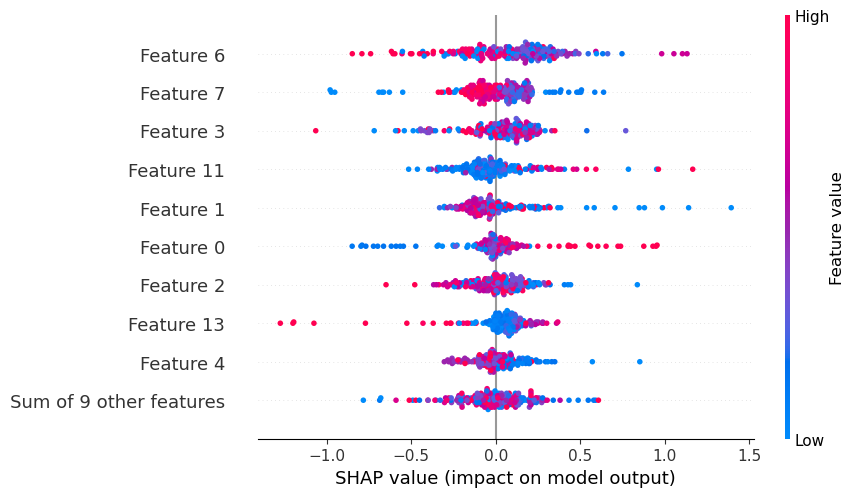

In [ ]:
import shap

shap_explainer = shap.Explainer(
    gb_best,
    X_train_balanced_Scaled
)

shap_values = shap_explainer(
    X_test_scaled
)

shap.plots.beeswarm(
    shap_values
)

In [ ]:
new_customer = X_test.iloc[[0]]

new_customer_scaled = scaler.transform(
    new_customer
)

prediction = stacking_model.predict(
    new_customer_scaled
)

probability = stacking_model.predict_proba(
    new_customer_scaled
)

if prediction[0] == 1:
    print("Customer is predicted to CHURN")
else:
    print("Customer is predicted to NOT CHURN")

print("Churn probability:", probability[0][1])

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int8DType'>, <class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.Int8DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>)

In [ ]:
import joblib

joblib.dump(
    svm_params,
    "churn_prediction.pkl"
)

joblib.dump(
    scaler,
    "churn_scaler.pkl"
)

print("Model and scaler saved successfully")

Model and scaler saved successfully


In [ ]:
# Check predictions on test data
test_predictions = model.predict(X_test)

print("Predicted classes:")
print(np.unique(test_predictions, return_counts=True))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int8DType'>, <class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.Int8DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>)